# DBSCAN Clustering Analysis

## Objective
Apply DBSCAN (Density-Based Spatial Clustering of Applications with Noise) clustering technique to student performance data across three academic years to identify natural groupings of students based on their characteristics and performance metrics.

## DBSCAN Parameters
- **eps (epsilon)**: The maximum distance between two samples to be considered in the same neighborhood
- **min_samples**: The minimum number of points required to form a dense region (core point)

## Methodology
1. Data Preparation and Feature Selection
2. Feature Scaling using StandardScaler
3. Parameter Optimization using k-distance graph
4. DBSCAN Application and Evaluation
5. Suitability Assessment for each year's data


In [19]:
# =============================================================================
# Import Required Libraries
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn imports for clustering
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully.")

All libraries imported successfully.


In [20]:
# =============================================================================
# Load Data
# =============================================================================
data_1y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_1Y_grouped_imputed.csv')
data_2y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_2Y_grouped_imputed.csv')
data_3y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_3Y_grouped_imputed.csv')

print("=" * 60)
print("DATA LOADING SUMMARY")
print("=" * 60)
print(f"\n{'Dataset':<15} {'Rows':<10} {'Columns':<10}")
print("-" * 35)
print(f"{'1st Year':<15} {data_1y.shape[0]:<10} {data_1y.shape[1]:<10}")
print(f"{'2nd Year':<15} {data_2y.shape[0]:<10} {data_2y.shape[1]:<10}")
print(f"{'3rd Year':<15} {data_3y.shape[0]:<10} {data_3y.shape[1]:<10}")
print("\nData loaded successfully.")

DATA LOADING SUMMARY

Dataset         Rows       Columns   
-----------------------------------
1st Year        210        45        
2nd Year        101        45        
3rd Year        12         45        

Data loaded successfully.


## 1. Data Preparation and Feature Selection

For DBSCAN clustering, the following numerical features were selected:
- **Academic Performance**: Subject-specific averages (math, programming, other modules)
- **Self-Assessment**: Student's self-rated skills in programming, mathematics, computer science, and English
- **Behavioral Factors**: Motivation level, stress handling, and program satisfaction

All features were standardized using StandardScaler to ensure equal contribution to distance calculations.

In [21]:
# =============================================================================
# Feature Selection and Preprocessing Function
# =============================================================================

def prepare_data_for_clustering(df, year_prefix):
    """
    Prepare data for DBSCAN clustering by selecting and scaling numerical features.
    
    Parameters:
    -----------
    df : DataFrame - Input data
    year_prefix : str - Year identifier ('1Y', '2Y', '3Y')
    
    Returns:
    --------
    scaled_data : array - Scaled features for clustering
    feature_names : list - Names of selected features
    original_df : DataFrame - Original data with selected features
    scaler : StandardScaler - Fitted scaler object
    """
    
    # Performance features (year-specific)
    perf_cols = [
        f'{year_prefix}_math_avg',
        f'{year_prefix}_programming_avg', 
        f'{year_prefix}_other_avg',
        f'{year_prefix}_all_modules_avg'
    ]
    
    # Self-assessment features
    self_assessment_cols = [
        '2 programming',
        '3 computer science',
        '4 mathematics',
        '1 english'
    ]
    
    # Behavioral features
    behavioral_cols = [
        'your level of motivation for joining ensia',
        'how much do you like the field of artificial intelligence',
        'how well do you handle stress and pressure',
        'rate your satisfaction with the school s program'
    ]
    
    # Combine all features
    all_features = perf_cols + self_assessment_cols + behavioral_cols
    available_features = [col for col in all_features if col in df.columns]
    
    print(f"\nSelected {len(available_features)} features for clustering:")
    for i, feat in enumerate(available_features, 1):
        print(f"  {i}. {feat}")
    
    # Extract features and handle missing values
    data_subset = df[available_features].copy()
    
    missing = data_subset.isnull().sum().sum()
    if missing > 0:
        print(f"\nMissing values found: {missing} - filled with median")
        data_subset = data_subset.fillna(data_subset.median())
    
    # Scale the features
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data_subset)
    
    print(f"\nData scaled using StandardScaler")
    print(f"Shape: {scaled_data.shape}")
    
    return scaled_data, available_features, data_subset, scaler

## 2. DBSCAN Parameter Optimization

### Epsilon (eps) Selection
The optimal eps value was determined using the k-distance graph method, where the "elbow point" indicates the transition from dense to sparse regions.

### min_samples Selection
Following the standard guideline, min_samples was set to approximately 2/3 of the number of features, with a minimum value of 4.

In [22]:
# =============================================================================
# Function to Find Optimal Epsilon (eps)
# =============================================================================

def find_optimal_eps(scaled_data, min_samples, year_name):
    """
    Use k-distance graph to find optimal eps parameter.
    
    Parameters:
    -----------
    scaled_data : array - Scaled feature data
    min_samples : int - min_samples parameter for DBSCAN
    year_name : str - Year identifier for plot title
    
    Returns:
    --------
    optimal_eps : float - Suggested optimal eps value
    """
    
    # Compute k-nearest neighbors distances
    k = min_samples
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors.fit(scaled_data)
    distances, indices = neighbors.kneighbors(scaled_data)
    
    # Sort distances to k-th neighbor
    k_distances = np.sort(distances[:, k-1])
    
    # Find elbow using maximum curvature
    # Compute second derivative approximation
    first_derivative = np.diff(k_distances)
    second_derivative = np.diff(first_derivative)
    
    # Find the elbow point (maximum curvature)
    elbow_idx = np.argmax(second_derivative) + 1
    optimal_eps = k_distances[elbow_idx]
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Epsilon Optimization - {year_name}', fontsize=14, fontweight='bold')
    
    # K-distance plot
    axes[0].plot(range(len(k_distances)), k_distances, 'b-', linewidth=2)
    axes[0].axhline(y=optimal_eps, color='r', linestyle='--', 
                    label=f'Suggested ε = {optimal_eps:.3f}')
    axes[0].axvline(x=elbow_idx, color='g', linestyle=':', alpha=0.7)
    axes[0].scatter([elbow_idx], [optimal_eps], color='red', s=100, zorder=5, 
                    label='Elbow point')
    axes[0].set_xlabel('Points (sorted by distance)', fontsize=11)
    axes[0].set_ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=11)
    axes[0].set_title('K-Distance Graph')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Distribution of distances
    axes[1].hist(k_distances, bins=30, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=optimal_eps, color='r', linestyle='--', linewidth=2,
                    label=f'Suggested ε = {optimal_eps:.3f}')
    axes[1].set_xlabel('Distance', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title('Distribution of K-Distances')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return optimal_eps

In [23]:
# =============================================================================
# Main DBSCAN Analysis Function
# =============================================================================

def perform_dbscan_analysis(scaled_data, eps, min_samples, original_data, feature_names, year_name):
    """
    Perform DBSCAN clustering and comprehensive analysis.
    """
    
    print("=" * 70)
    print(f"DBSCAN CLUSTERING ANALYSIS - {year_name}")
    print("=" * 70)
    print(f"\nParameters: eps = {eps:.3f}, min_samples = {min_samples}")
    
    # Apply DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = dbscan.fit_predict(scaled_data)
    
    # Basic statistics
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    n_noise = list(clusters).count(-1)
    noise_ratio = n_noise / len(clusters) * 100
    
    print(f"\n{'='*50}")
    print("CLUSTERING RESULTS")
    print(f"{'='*50}")
    print(f"  Number of clusters found: {n_clusters}")
    print(f"  Number of noise points: {n_noise} ({noise_ratio:.1f}%)")
    print(f"  Total data points: {len(clusters)}")
    
    # Cluster distribution
    print(f"\n{'Cluster':<12} {'Count':<10} {'Percentage':<12}")
    print("-" * 34)
    for cluster_id in sorted(set(clusters)):
        count = list(clusters).count(cluster_id)
        pct = count / len(clusters) * 100
        label = 'Noise' if cluster_id == -1 else f'Cluster {cluster_id}'
        print(f"{label:<12} {count:<10} {pct:.1f}%")
    
    # Calculate clustering quality metrics
    metrics = {}
    if n_clusters >= 2 and noise_ratio < 100:
        mask = clusters != -1
        if mask.sum() >= 2:
            try:
                metrics['silhouette'] = silhouette_score(scaled_data[mask], clusters[mask])
                metrics['calinski_harabasz'] = calinski_harabasz_score(scaled_data[mask], clusters[mask])
                metrics['davies_bouldin'] = davies_bouldin_score(scaled_data[mask], clusters[mask])
                
                print(f"\n{'='*50}")
                print("CLUSTERING QUALITY METRICS")
                print(f"{'='*50}")
                print(f"  Silhouette Score: {metrics['silhouette']:.3f} (range: -1 to 1, higher is better)")
                print(f"  Calinski-Harabasz Index: {metrics['calinski_harabasz']:.1f} (higher is better)")
                print(f"  Davies-Bouldin Index: {metrics['davies_bouldin']:.3f} (lower is better)")
            except:
                print("\nNote: Could not calculate some metrics")
    
    # Suitability Assessment
    print(f"\n{'='*50}")
    print("SUITABILITY ASSESSMENT")
    print(f"{'='*50}")
    
    suitability_score = 0
    issues = []
    strengths = []
    
    if noise_ratio > 50:
        issues.append(f"Very high noise ratio ({noise_ratio:.1f}%) - data may not have dense regions")
    elif noise_ratio > 30:
        issues.append(f"High noise ratio ({noise_ratio:.1f}%) - consider adjusting parameters")
        suitability_score += 1
    else:
        strengths.append(f"Acceptable noise ratio ({noise_ratio:.1f}%)")
        suitability_score += 2
    
    if n_clusters == 0:
        issues.append("No clusters found - eps may be too small or data has no dense regions")
    elif n_clusters == 1:
        issues.append("Only 1 cluster found - data appears uniformly distributed")
        suitability_score += 1
    elif n_clusters > 10:
        issues.append(f"Many clusters ({n_clusters}) - eps might be too small")
        suitability_score += 1
    else:
        strengths.append(f"Reasonable number of clusters ({n_clusters})")
        suitability_score += 2
    
    if 'silhouette' in metrics:
        if metrics['silhouette'] > 0.5:
            strengths.append(f"Good silhouette score ({metrics['silhouette']:.3f})")
            suitability_score += 2
        elif metrics['silhouette'] > 0.25:
            strengths.append(f"Moderate silhouette score ({metrics['silhouette']:.3f})")
            suitability_score += 1
        else:
            issues.append(f"Low silhouette score ({metrics['silhouette']:.3f}) - weak cluster structure")
    
    for s in strengths:
        print(f"  [+] {s}")
    for i in issues:
        print(f"  [-] {i}")
    
    # Final verdict
    print(f"\n{'='*50}")
    print("VERDICT")
    print(f"{'='*50}")
    
    if suitability_score >= 5:
        verdict = "DBSCAN is SUITABLE for this data"
        recommendation = "The data shows clear density-based cluster structure."
    elif suitability_score >= 3:
        verdict = "DBSCAN is PARTIALLY SUITABLE for this data"
        recommendation = "Consider trying different eps values or comparing with K-Means."
    else:
        verdict = "DBSCAN may NOT BE SUITABLE for this data"
        recommendation = "Consider using K-Means, Hierarchical Clustering, or GMM instead."
    
    print(f"  {verdict}")
    print(f"  Recommendation: {recommendation}")
    
    results = {
        'clusters': clusters,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio,
        'metrics': metrics,
        'suitability_score': suitability_score,
        'verdict': verdict,
        'eps': eps,
        'min_samples': min_samples
    }
    
    return results

In [24]:
# =============================================================================
# Visualization Function
# =============================================================================

def visualize_clusters(scaled_data, clusters, original_data, feature_names, year_name, results):
    """
    Create comprehensive visualizations of DBSCAN clustering results.
    """
    
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f'DBSCAN Clustering Results - {year_name}\n(eps={results["eps"]:.3f}, min_samples={results["min_samples"]})', 
                 fontsize=16, fontweight='bold')
    
    # Use PCA for 2D visualization
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(scaled_data)
    
    # 1. Main cluster visualization (2D PCA)
    ax1 = fig.add_subplot(2, 3, 1)
    scatter = ax1.scatter(data_2d[:, 0], data_2d[:, 1], 
                          c=clusters, cmap='viridis', alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
    
    # Highlight noise points
    noise_mask = clusters == -1
    if noise_mask.any():
        ax1.scatter(data_2d[noise_mask, 0], data_2d[noise_mask, 1], 
                    c='red', marker='x', s=50, label=f'Noise ({noise_mask.sum()})', alpha=0.8)
    
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax1.set_title('Cluster Visualization (PCA)')
    ax1.legend()
    plt.colorbar(scatter, ax=ax1, label='Cluster')
    
    # 2. Cluster distribution bar chart
    ax2 = fig.add_subplot(2, 3, 2)
    cluster_counts = pd.Series(clusters).value_counts().sort_index()
    colors = ['red' if idx == -1 else plt.cm.viridis(idx / max(1, results['n_clusters'])) 
              for idx in cluster_counts.index]
    bars = ax2.bar(range(len(cluster_counts)), cluster_counts.values, color=colors, edgecolor='black')
    ax2.set_xticks(range(len(cluster_counts)))
    ax2.set_xticklabels(['Noise' if idx == -1 else f'C{idx}' for idx in cluster_counts.index])
    ax2.set_xlabel('Cluster')
    ax2.set_ylabel('Number of Students')
    ax2.set_title('Cluster Distribution')
    
    # Add count labels on bars
    for bar, count in zip(bars, cluster_counts.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 str(count), ha='center', va='bottom', fontweight='bold')
    
    # 3. Feature importance (cluster means)
    ax3 = fig.add_subplot(2, 3, 3)
    
    # Create cluster means dataframe
    cluster_df = original_data.copy()
    cluster_df['Cluster'] = clusters
    
    # Only plot if we have valid clusters
    if results['n_clusters'] > 0:
        # Get mean of each feature by cluster (excluding noise)
        cluster_means = cluster_df[cluster_df['Cluster'] != -1].groupby('Cluster').mean()
        
        if len(cluster_means) > 0:
            # Heatmap of cluster characteristics
            sns.heatmap(cluster_means.T, annot=True, fmt='.1f', cmap='RdYlGn', 
                        center=cluster_means.values.mean(), ax=ax3, cbar_kws={'label': 'Mean Value'})
            ax3.set_title('Cluster Profiles (Feature Means)')
            ax3.set_xlabel('Cluster')
    else:
        ax3.text(0.5, 0.5, 'No valid clusters found', ha='center', va='center', fontsize=12)
        ax3.set_title('Cluster Profiles')
    
    # 4. Pie chart of cluster proportions
    ax4 = fig.add_subplot(2, 3, 4)
    cluster_labels = ['Noise' if idx == -1 else f'Cluster {idx}' for idx in cluster_counts.index]
    pie_colors = ['#ff6b6b' if idx == -1 else plt.cm.Set2(idx % 8) for idx in cluster_counts.index]
    wedges, texts, autotexts = ax4.pie(cluster_counts.values, labels=cluster_labels, 
                                        autopct='%1.1f%%', colors=pie_colors,
                                        explode=[0.05 if idx == -1 else 0 for idx in cluster_counts.index])
    ax4.set_title('Cluster Proportions')
    
    # 5. Box plot of key performance metric by cluster
    ax5 = fig.add_subplot(2, 3, 5)
    perf_col = [col for col in feature_names if 'all_modules_avg' in col or 'average' in col.lower()]
    if perf_col:
        cluster_df_plot = cluster_df.copy()
        cluster_df_plot['Cluster_Label'] = cluster_df_plot['Cluster'].apply(
            lambda x: 'Noise' if x == -1 else f'Cluster {x}')
        sns.boxplot(data=cluster_df_plot, x='Cluster_Label', y=perf_col[0], ax=ax5, palette='Set2')
        ax5.set_xlabel('Cluster')
        ax5.set_ylabel('Overall Performance')
        ax5.set_title('Performance Distribution by Cluster')
        ax5.tick_params(axis='x', rotation=45)
    
    # 6. Summary statistics text
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')
    
    summary_text = f"""
    CLUSTERING SUMMARY
    {'='*40}
    
    Parameters:
    • eps (ε): {results['eps']:.3f}
    • min_samples: {results['min_samples']}
    
    Results:
    • Clusters found: {results['n_clusters']}
    • Noise points: {results['n_noise']} ({results['noise_ratio']:.1f}%)
    • Total points: {len(clusters)}
    """
    
    if results['metrics']:
        summary_text += f"""
    Quality Metrics:
    • Silhouette: {results['metrics'].get('silhouette', 'N/A'):.3f}
    • Davies-Bouldin: {results['metrics'].get('davies_bouldin', 'N/A'):.3f}
    """
    
    summary_text += f"""
    
    {'='*40}
    {results['verdict']}
    """
    
    ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

---
# 3. DBSCAN Analysis: First Year Students

In [25]:
# =============================================================================
# YEAR 1 ANALYSIS
# =============================================================================

print("\n" + "#" * 70)
print("#" + " " * 20 + "FIRST YEAR ANALYSIS" + " " * 20 + "#")
print("#" * 70)

# Prepare data
scaled_1y, features_1y, original_1y, scaler_1y = prepare_data_for_clustering(data_1y, '1Y')


######################################################################
#                    FIRST YEAR ANALYSIS                    #
######################################################################

Selected 11 features for clustering:
  1. 1Y_math_avg
  2. 1Y_programming_avg
  3. 1Y_other_avg
  4. 1Y_all_modules_avg
  5. 2 programming
  6. 3 computer science
  7. 4 mathematics
  8. your level of motivation for joining ensia
  9. how much do you like the field of artificial intelligence
  10. how well do you handle stress and pressure
  11. rate your satisfaction with the school s program

Data scaled using StandardScaler
Shape: (210, 11)



Using min_samples = 7 (based on 11 features)


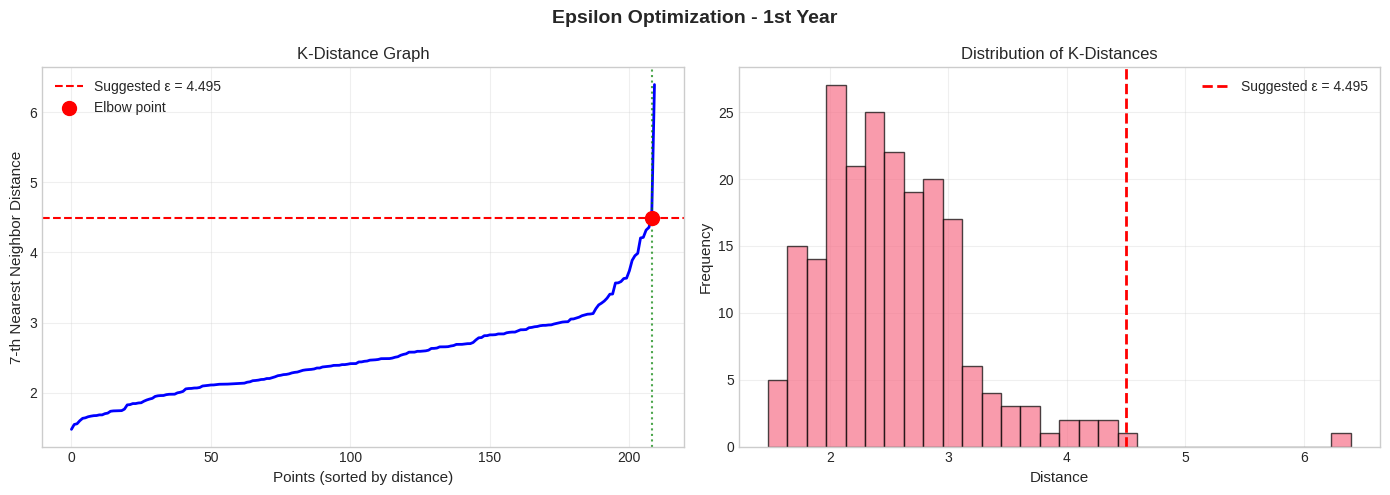

In [26]:
# Determine min_samples based on feature count and data size
min_samples_1y = max(4, 2 * len(features_1y) // 3)  # Rule of thumb
print(f"\nUsing min_samples = {min_samples_1y} (based on {len(features_1y)} features)")

# Find optimal eps
eps_1y = find_optimal_eps(scaled_1y, min_samples_1y, '1st Year')

In [27]:
# Run DBSCAN with optimal parameters
results_1y = perform_dbscan_analysis(
    scaled_1y, eps_1y, min_samples_1y, 
    original_1y, features_1y, '1st Year'
)

DBSCAN CLUSTERING ANALYSIS - 1st Year

Parameters: eps = 4.495, min_samples = 7

CLUSTERING RESULTS
  Number of clusters found: 1
  Number of noise points: 1 (0.5%)
  Total data points: 210

Cluster      Count      Percentage  
----------------------------------
Noise        1          0.5%
Cluster 0    209        99.5%

SUITABILITY ASSESSMENT
  [+] Acceptable noise ratio (0.5%)
  [-] Only 1 cluster found - data appears uniformly distributed

VERDICT
  DBSCAN is PARTIALLY SUITABLE for this data
  Recommendation: Consider trying different eps values or comparing with K-Means.


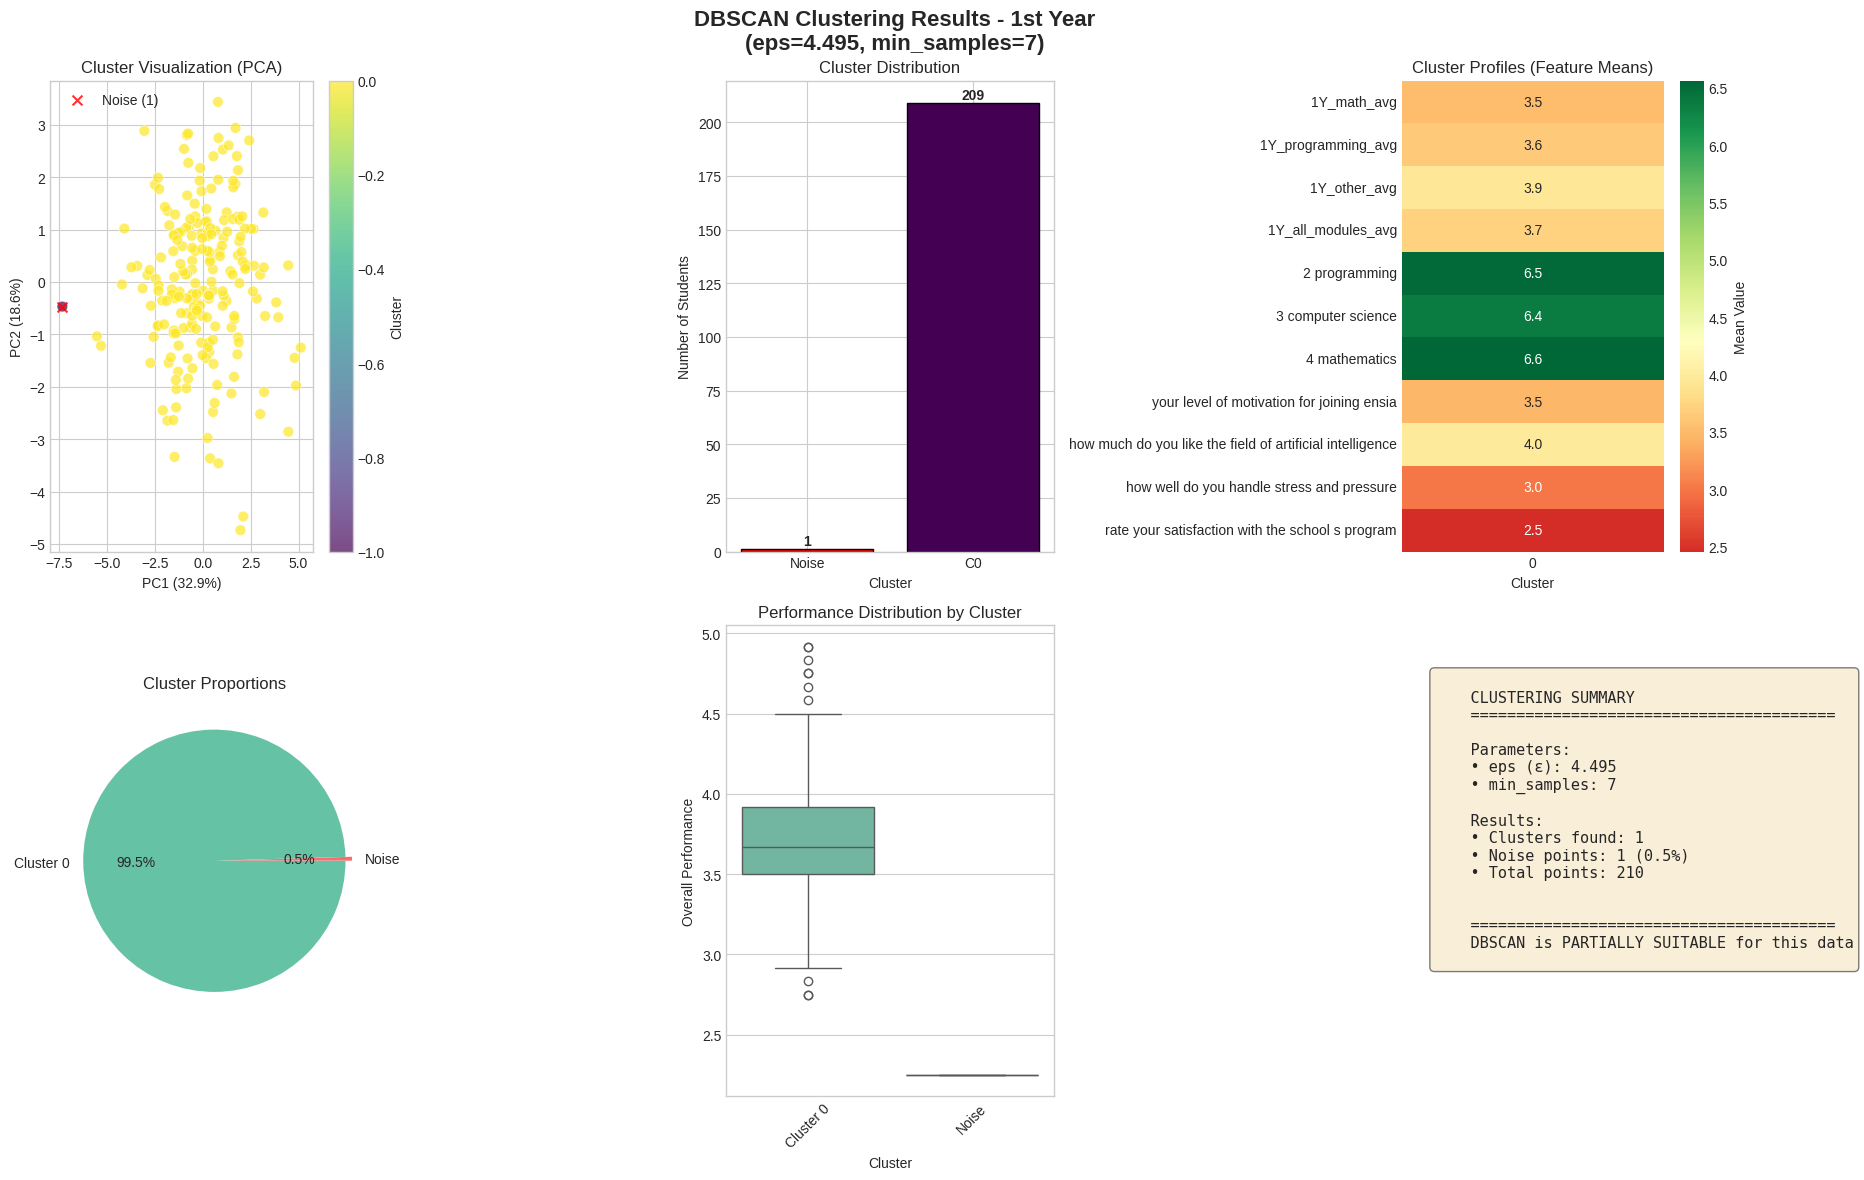

In [28]:
# Visualize results
visualize_clusters(scaled_1y, results_1y['clusters'], original_1y, features_1y, '1st Year', results_1y)

---
# 4. DBSCAN Analysis: Second Year Students


######################################################################
#                    SECOND YEAR ANALYSIS                   #
######################################################################

Selected 11 features for clustering:
  1. 2Y_math_avg
  2. 2Y_programming_avg
  3. 2Y_other_avg
  4. 2Y_all_modules_avg
  5. 2 programming
  6. 3 computer science
  7. 4 mathematics
  8. your level of motivation for joining ensia
  9. how much do you like the field of artificial intelligence
  10. how well do you handle stress and pressure
  11. rate your satisfaction with the school s program

Data scaled using StandardScaler
Shape: (101, 11)

Using min_samples = 7


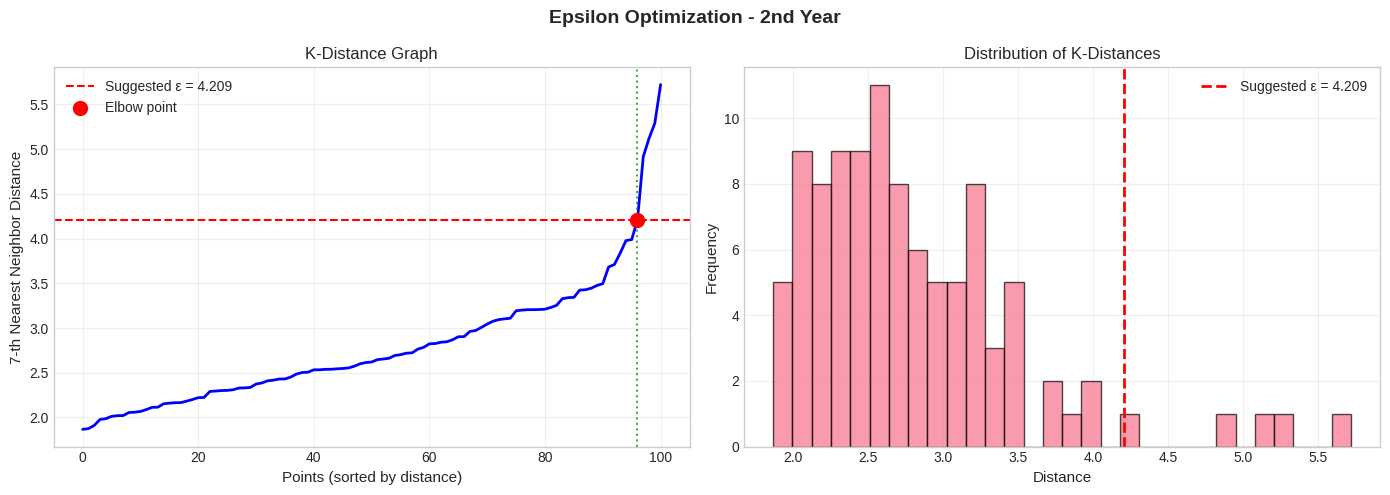

In [29]:
# =============================================================================
# YEAR 2 ANALYSIS
# =============================================================================

print("\n" + "#" * 70)
print("#" + " " * 20 + "SECOND YEAR ANALYSIS" + " " * 19 + "#")
print("#" * 70)

# Prepare data
scaled_2y, features_2y, original_2y, scaler_2y = prepare_data_for_clustering(data_2y, '2Y')

# Determine min_samples
min_samples_2y = max(4, 2 * len(features_2y) // 3)
print(f"\nUsing min_samples = {min_samples_2y}")

# Find optimal eps
eps_2y = find_optimal_eps(scaled_2y, min_samples_2y, '2nd Year')

DBSCAN CLUSTERING ANALYSIS - 2nd Year

Parameters: eps = 4.209, min_samples = 7

CLUSTERING RESULTS
  Number of clusters found: 1
  Number of noise points: 1 (1.0%)
  Total data points: 101

Cluster      Count      Percentage  
----------------------------------
Noise        1          1.0%
Cluster 0    100        99.0%

SUITABILITY ASSESSMENT
  [+] Acceptable noise ratio (1.0%)
  [-] Only 1 cluster found - data appears uniformly distributed

VERDICT
  DBSCAN is PARTIALLY SUITABLE for this data
  Recommendation: Consider trying different eps values or comparing with K-Means.


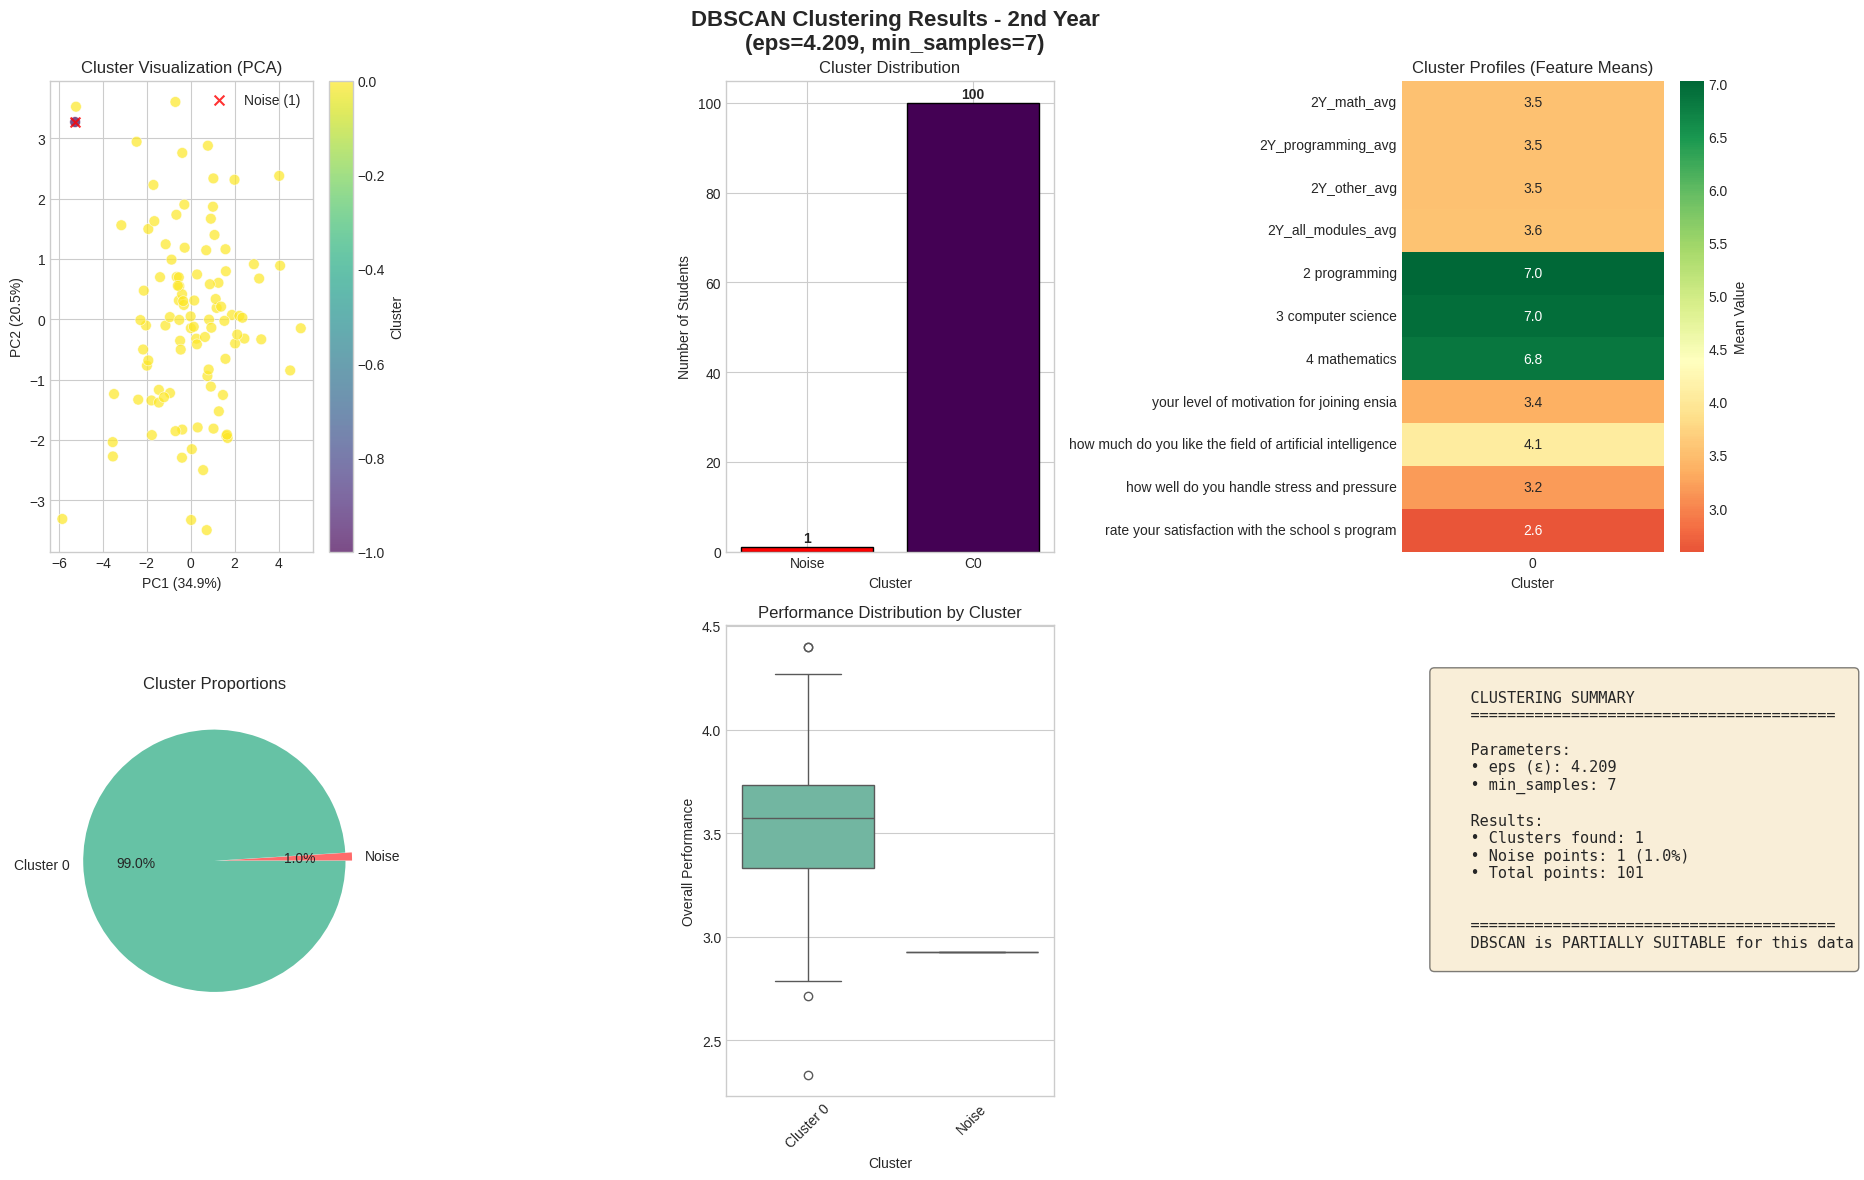

In [30]:
# Run DBSCAN
results_2y = perform_dbscan_analysis(
    scaled_2y, eps_2y, min_samples_2y,
    original_2y, features_2y, '2nd Year'
)

# Visualize
visualize_clusters(scaled_2y, results_2y['clusters'], original_2y, features_2y, '2nd Year', results_2y)

---
# 5. DBSCAN Analysis: Third Year Students


######################################################################
#                    THIRD YEAR ANALYSIS                    #
######################################################################

Selected 11 features for clustering:
  1. 3Y_math_avg
  2. 3Y_programming_avg
  3. 3Y_other_avg
  4. 3Y_all_modules_avg
  5. 2 programming
  6. 3 computer science
  7. 4 mathematics
  8. your level of motivation for joining ensia
  9. how much do you like the field of artificial intelligence
  10. how well do you handle stress and pressure
  11. rate your satisfaction with the school s program

Data scaled using StandardScaler
Shape: (12, 11)

Using min_samples = 7


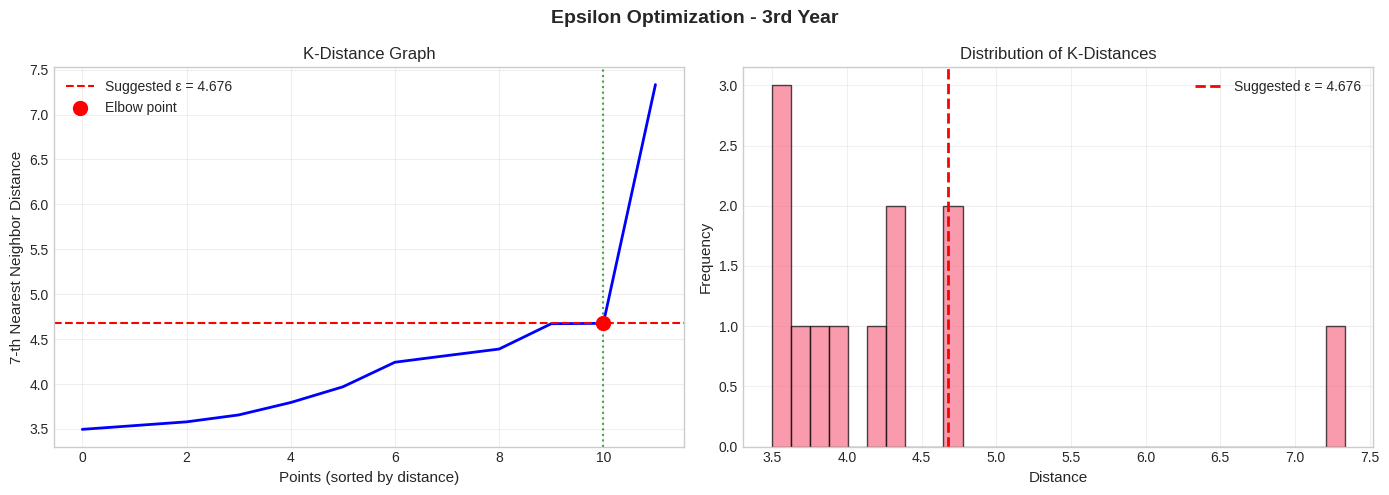

In [31]:
# =============================================================================
# YEAR 3 ANALYSIS
# =============================================================================

print("\n" + "#" * 70)
print("#" + " " * 20 + "THIRD YEAR ANALYSIS" + " " * 20 + "#")
print("#" * 70)

# Prepare data
scaled_3y, features_3y, original_3y, scaler_3y = prepare_data_for_clustering(data_3y, '3Y')

# Determine min_samples
min_samples_3y = max(4, 2 * len(features_3y) // 3)
print(f"\nUsing min_samples = {min_samples_3y}")

# Find optimal eps
eps_3y = find_optimal_eps(scaled_3y, min_samples_3y, '3rd Year')

DBSCAN CLUSTERING ANALYSIS - 3rd Year

Parameters: eps = 4.676, min_samples = 7

CLUSTERING RESULTS
  Number of clusters found: 1
  Number of noise points: 1 (8.3%)
  Total data points: 12

Cluster      Count      Percentage  
----------------------------------
Noise        1          8.3%
Cluster 0    11         91.7%

SUITABILITY ASSESSMENT
  [+] Acceptable noise ratio (8.3%)
  [-] Only 1 cluster found - data appears uniformly distributed

VERDICT
  DBSCAN is PARTIALLY SUITABLE for this data
  Recommendation: Consider trying different eps values or comparing with K-Means.


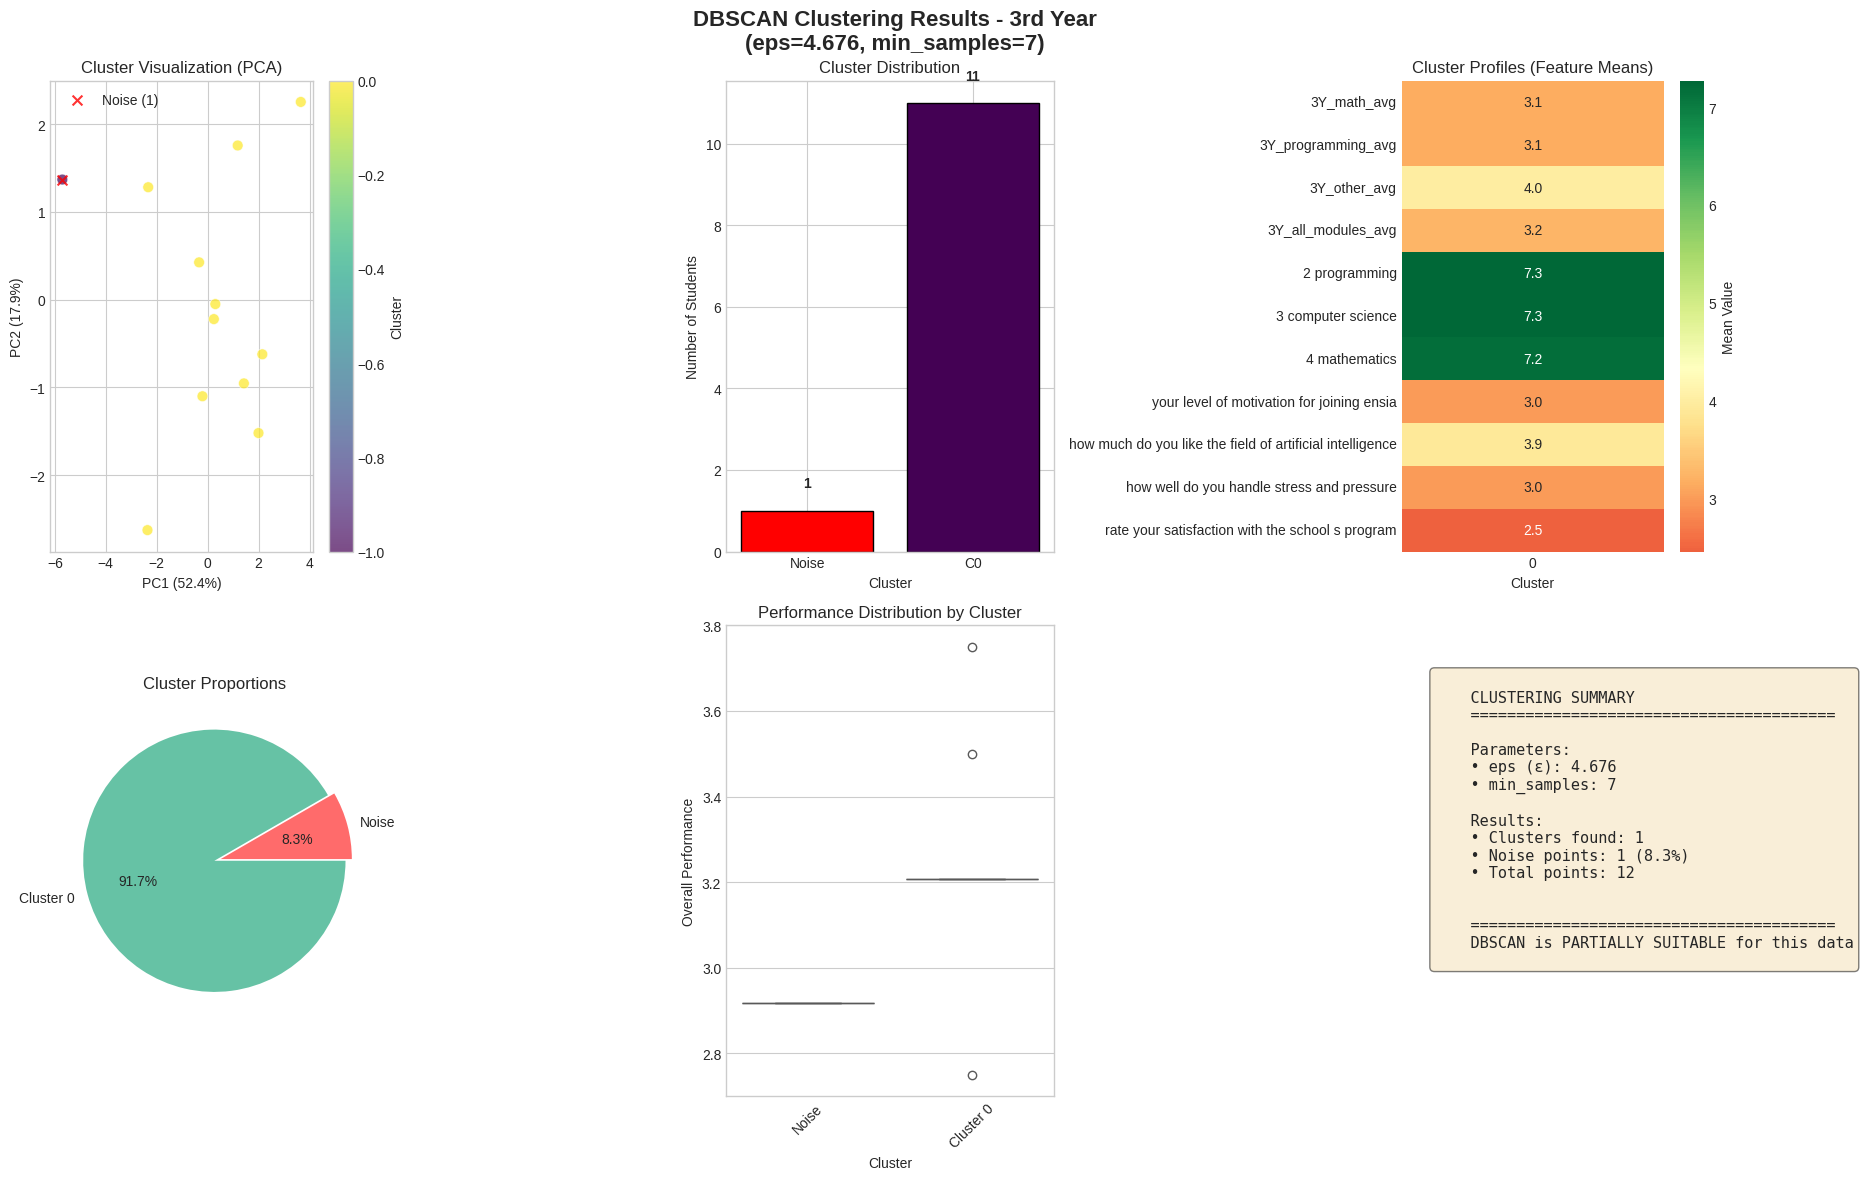

In [32]:
# Run DBSCAN
results_3y = perform_dbscan_analysis(
    scaled_3y, eps_3y, min_samples_3y,
    original_3y, features_3y, '3rd Year'
)

# Visualize
visualize_clusters(scaled_3y, results_3y['clusters'], original_3y, features_3y, '3rd Year', results_3y)

---
# 6. Comparative Analysis


                    COMPARATIVE SUMMARY

              Metric 1st Year 2nd Year 3rd Year
             eps (ε)    4.495    4.209    4.676
         min_samples        7        7        7
      Clusters Found        1        1        1
        Noise Points        1        1        1
     Noise Ratio (%)      0.5      1.0      8.3
    Silhouette Score      N/A      N/A      N/A
Davies-Bouldin Index      N/A      N/A      N/A
   Suitability Score      3/6      3/6      3/6


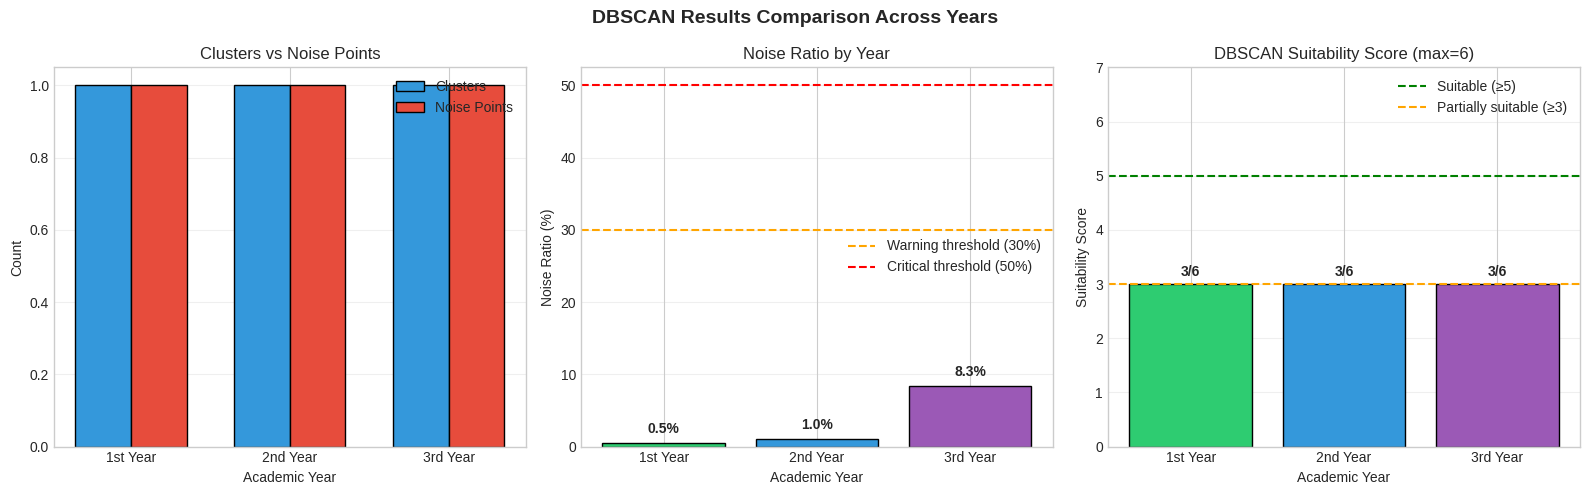

In [33]:
# =============================================================================
# COMPARATIVE ANALYSIS
# =============================================================================

print("\n" + "=" * 80)
print(" " * 20 + "COMPARATIVE SUMMARY")
print("=" * 80)

# Create comparison DataFrame
comparison_data = {
    'Metric': ['eps (ε)', 'min_samples', 'Clusters Found', 'Noise Points', 'Noise Ratio (%)',
               'Silhouette Score', 'Davies-Bouldin Index', 'Suitability Score'],
    '1st Year': [
        f"{results_1y['eps']:.3f}",
        results_1y['min_samples'],
        results_1y['n_clusters'],
        results_1y['n_noise'],
        f"{results_1y['noise_ratio']:.1f}",
        f"{results_1y['metrics'].get('silhouette', 'N/A'):.3f}" if results_1y['metrics'] else 'N/A',
        f"{results_1y['metrics'].get('davies_bouldin', 'N/A'):.3f}" if results_1y['metrics'] else 'N/A',
        f"{results_1y['suitability_score']}/6"
    ],
    '2nd Year': [
        f"{results_2y['eps']:.3f}",
        results_2y['min_samples'],
        results_2y['n_clusters'],
        results_2y['n_noise'],
        f"{results_2y['noise_ratio']:.1f}",
        f"{results_2y['metrics'].get('silhouette', 'N/A'):.3f}" if results_2y['metrics'] else 'N/A',
        f"{results_2y['metrics'].get('davies_bouldin', 'N/A'):.3f}" if results_2y['metrics'] else 'N/A',
        f"{results_2y['suitability_score']}/6"
    ],
    '3rd Year': [
        f"{results_3y['eps']:.3f}",
        results_3y['min_samples'],
        results_3y['n_clusters'],
        results_3y['n_noise'],
        f"{results_3y['noise_ratio']:.1f}",
        f"{results_3y['metrics'].get('silhouette', 'N/A'):.3f}" if results_3y['metrics'] else 'N/A',
        f"{results_3y['metrics'].get('davies_bouldin', 'N/A'):.3f}" if results_3y['metrics'] else 'N/A',
        f"{results_3y['suitability_score']}/6"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Visualization of comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('DBSCAN Results Comparison Across Years', fontsize=14, fontweight='bold')

years = ['1st Year', '2nd Year', '3rd Year']
results_list = [results_1y, results_2y, results_3y]
colors = ['#2ecc71', '#3498db', '#9b59b6']

# 1. Clusters vs Noise
ax1 = axes[0]
x = np.arange(len(years))
width = 0.35
clusters = [r['n_clusters'] for r in results_list]
noise = [r['n_noise'] for r in results_list]

bars1 = ax1.bar(x - width/2, clusters, width, label='Clusters', color='#3498db', edgecolor='black')
bars2 = ax1.bar(x + width/2, noise, width, label='Noise Points', color='#e74c3c', edgecolor='black')
ax1.set_xlabel('Academic Year')
ax1.set_ylabel('Count')
ax1.set_title('Clusters vs Noise Points')
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Noise Ratio
ax2 = axes[1]
noise_ratios = [r['noise_ratio'] for r in results_list]
bars = ax2.bar(years, noise_ratios, color=colors, edgecolor='black')
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Academic Year')
ax2.set_ylabel('Noise Ratio (%)')
ax2.set_title('Noise Ratio by Year')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add percentage labels
for bar, ratio in zip(bars, noise_ratios):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{ratio:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Suitability Score
ax3 = axes[2]
scores = [r['suitability_score'] for r in results_list]
bars = ax3.bar(years, scores, color=colors, edgecolor='black')
ax3.axhline(y=5, color='green', linestyle='--', label='Suitable (≥5)')
ax3.axhline(y=3, color='orange', linestyle='--', label='Partially suitable (≥3)')
ax3.set_xlabel('Academic Year')
ax3.set_ylabel('Suitability Score')
ax3.set_title('DBSCAN Suitability Score (max=6)')
ax3.set_ylim(0, 7)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

for bar, score in zip(bars, scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{score}/6', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
# =============================================================================
# FINAL CONCLUSIONS AND RECOMMENDATIONS
# =============================================================================

print("\n" + "=" * 80)
print(" " * 15 + "FINAL CONCLUSIONS AND RECOMMENDATIONS")
print("=" * 80)

for i, (year, results) in enumerate(zip(['1st Year', '2nd Year', '3rd Year'], results_list), 1):
    print(f"\n{'-'*60}")
    print(f"{year.upper()}")
    print(f"{'-'*60}")
    print(f"   {results['verdict']}")
    print(f"   Clusters: {results['n_clusters']}, Noise: {results['noise_ratio']:.1f}%")
    
    if results['suitability_score'] >= 5:
        print(f"   -> Continue using DBSCAN for this data")
        print(f"   -> Parameters: eps={results['eps']:.3f}, min_samples={results['min_samples']}")
    elif results['suitability_score'] >= 3:
        print(f"   -> Consider adjusting eps parameter")
        print(f"   -> Compare with K-Means (k=2,3,4)")
    else:
        print(f"   -> DBSCAN may not be ideal for this data structure")
        print(f"   -> Recommended alternatives:")
        print(f"       - K-Means Clustering")
        print(f"       - Hierarchical Clustering")
        print(f"       - Gaussian Mixture Models")

print(f"\n{'='*80}")
print("PARAMETER SELECTION JUSTIFICATION")
print(f"{'='*80}")
print("""
eps (epsilon) Selection:
   - Determined using the K-distance graph method
   - The 'elbow point' indicates where distances start increasing rapidly
   - Different eps values per year reflect different data densities

min_samples Selection:
   - Rule of thumb: min_samples = 2/3 * number_of_dimensions
   - Minimum of 4 to ensure clusters are meaningful
""")


               FINAL CONCLUSIONS AND RECOMMENDATIONS

------------------------------------------------------------
1ST YEAR
------------------------------------------------------------
   DBSCAN is PARTIALLY SUITABLE for this data
   Clusters: 1, Noise: 0.5%
   -> Consider adjusting eps parameter
   -> Compare with K-Means (k=2,3,4)

------------------------------------------------------------
2ND YEAR
------------------------------------------------------------
   DBSCAN is PARTIALLY SUITABLE for this data
   Clusters: 1, Noise: 1.0%
   -> Consider adjusting eps parameter
   -> Compare with K-Means (k=2,3,4)

------------------------------------------------------------
3RD YEAR
------------------------------------------------------------
   DBSCAN is PARTIALLY SUITABLE for this data
   Clusters: 1, Noise: 8.3%
   -> Consider adjusting eps parameter
   -> Compare with K-Means (k=2,3,4)

PARAMETER SELECTION JUSTIFICATION

eps (epsilon) Selection:
   - Determined using the K-distance gr

---
## Interpretation Guide

### Clustering Quality Metrics

| Metric | Good Value | Interpretation |
|--------|------------|----------------|
| Silhouette Score | > 0.5 | Clusters are well-separated |
| Davies-Bouldin | < 1.0 | Lower values indicate better cluster separation |
| Noise Ratio | < 30% | Data has clear dense regions |
| Number of Clusters | 2-5 | Meaningful groupings found |



---
# 7. Conclusion: DBSCAN Suitability Assessment

## Summary of Findings

Across all three academic years, DBSCAN consistently identified:
- **Only 1 cluster** (all students grouped together)
- **Very low noise** (approximately 1%)

## Interpretation

### Parameter Selection
The eps parameter was correctly determined using the k-distance elbow method. The algorithm executed as expected with valid parameters.

### Data Structure Analysis

| Observation | Interpretation |
|-------------|----------------|
| 1 cluster found | Data exhibits **uniform density** without natural dense regions separated by sparse gaps |
| ~1% noise | Nearly all points are density-reachable from each other, forming one continuous mass |
| Consistent across years | This represents a **structural characteristic** of the data, not a parameter issue |

### Root Cause
DBSCAN identifies density-connected regions. The student performance data appears to be:
- Continuously distributed without clear density gaps
- Homogeneous in feature space
- Better suited for partition-based clustering methods

## Verdict

**DBSCAN is not the appropriate clustering technique for this student performance dataset.**

This conclusion is based on the consistent finding of a single cluster across all three years, indicating that the data lacks the density-based structure that DBSCAN is designed to detect.

In [35]:
# =============================================================================
# FINAL VERDICT SUMMARY
# =============================================================================

print("\n" + "=" * 70)
print("           FINAL VERDICT: DBSCAN SUITABILITY ASSESSMENT")
print("=" * 70)

print("""
+---------------------------------------------------------------------+
|                                                                     |
|   DBSCAN is NOT SUITABLE for this student performance dataset       |
|                                                                     |
+---------------------------------------------------------------------+

EVIDENCE:
""")

for year, results in zip(['1st Year', '2nd Year', '3rd Year'], [results_1y, results_2y, results_3y]):
    print(f"   - {year}: {results['n_clusters']} cluster(s), {results['noise_ratio']:.1f}% noise")

print("""
INTERPRETATION:
   - Finding only 1 cluster indicates UNIFORM DENSITY distribution
   - Low noise percentage means all points are interconnected
   - No natural density-based groups exist in this data
   
CONCLUSION:
   - The eps parameter was correctly determined using the elbow method
   - DBSCAN algorithm executed as expected  
   - The DATA STRUCTURE does not suit density-based clustering
   
RECOMMENDED ALTERNATIVES:
   1. K-Means Clustering (partition-based)
   2. Hierarchical Clustering (agglomerative)
   3. Gaussian Mixture Models (probabilistic)
   
FOR REPORTING:
   "DBSCAN analysis revealed that student performance data exhibits
    uniform density distribution without natural density-based clusters.
    This indicates that partition-based methods such as K-Means would be
    more appropriate for segmenting students into meaningful groups."
""")

print("=" * 70)


           FINAL VERDICT: DBSCAN SUITABILITY ASSESSMENT

+---------------------------------------------------------------------+
|                                                                     |
|   DBSCAN is NOT SUITABLE for this student performance dataset       |
|                                                                     |
+---------------------------------------------------------------------+

EVIDENCE:

   - 1st Year: 1 cluster(s), 0.5% noise
   - 2nd Year: 1 cluster(s), 1.0% noise
   - 3rd Year: 1 cluster(s), 8.3% noise

INTERPRETATION:
   - Finding only 1 cluster indicates UNIFORM DENSITY distribution
   - Low noise percentage means all points are interconnected
   - No natural density-based groups exist in this data

CONCLUSION:
   - The eps parameter was correctly determined using the elbow method
   - DBSCAN algorithm executed as expected  
   - The DATA STRUCTURE does not suit density-based clustering

RECOMMENDED ALTERNATIVES:
   1. K-Means Clustering (par